Running VGGNet (BCE, Adam, 10 Epochs)...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 227ms/step - accuracy: 0.9542 - loss: 0.1472 - val_accuracy: 0.9845 - val_loss: 0.0460
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9899 - val_loss: 0.0335
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 202ms/step - accuracy: 0.9919 - loss: 0.0253 - val_accuracy: 0.9901 - val_loss: 0.0302
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 217ms/step - accuracy: 0.9940 - loss: 0.0187 - val_accuracy: 0.9923 - val_loss: 0.0237
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 106s 226ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.9924 - val_loss: 0.0233
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 229ms/step - accuracy: 0.9972 - loss: 0.0088 - val_accuracy: 0.9939 - val_loss: 0.0206
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0.9929 - val_loss: 0.0221
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━

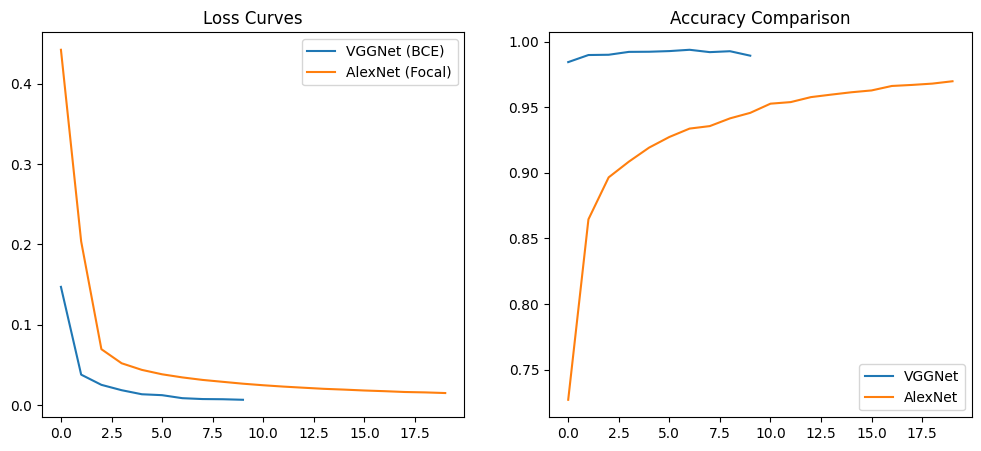


Part 2 Comparison Table:
  Model Optimizer  Epochs Loss Function  Training Accuracy  Testing Accuracy
 VGGNet      Adam      10           BCE            0.99775            0.9894
AlexNet       SGD      20    Focal Loss            0.96110            0.9699


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[..., None] / 255.0
x_test = x_test[..., None] / 255.0

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), 10)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        loss = -y_true * alpha * tf.pow(1 - y_pred, gamma) * tf.math.log(y_pred)
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

class ArcFaceLayer(layers.Layer):
    def __init__(self, n_classes=10, s=30.0, m=0.50):
        super(ArcFaceLayer, self).__init__()
        self.n_classes = n_classes
        self.s = s
        self.m = m
    def build(self, input_shape):
        self.W = self.add_weight(name='W', shape=(input_shape[-1], self.n_classes), initializer='glorot_uniform', trainable=True)
    def call(self, embedding, labels):
        embedding = tf.nn.l2_normalize(embedding, axis=1)
        W = tf.nn.l2_normalize(self.W, axis=0)
        cos_m = tf.math.cos(self.m)
        sin_m = tf.math.sin(self.m)
        cos_t = tf.matmul(embedding, W)
        sin_t = tf.sqrt(1.0 - tf.square(cos_t))
        cos_mt = cos_t * cos_m - sin_t * sin_m
        one_hot = tf.one_hot(tf.cast(labels, tf.int32), self.n_classes)
        output = (one_hot * cos_mt) + ((1.0 - one_hot) * cos_t)
        return output * self.s

def get_lenet5():
    return models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(6, (5, 5), activation='tanh', padding='same'),
        layers.AveragePooling2D(),
        layers.Conv2D(16, (5, 5), activation='tanh'),
        layers.AveragePooling2D(),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])

def get_vgg_mnist():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def get_alexnet_mnist():
    return models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(96, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(384, (3,3), padding='same', activation='relu'),
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

results = []

print("Running VGGNet (BCE, Adam, 10 Epochs)...")
vgg = get_vgg_mnist()
vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_vgg = vgg.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_test, y_test))
results.append(["VGGNet", "Adam", 10, "BCE", h_vgg.history['accuracy'][-1], h_vgg.history['val_accuracy'][-1]])

print("Running AlexNet (Focal Loss, SGD, 20 Epochs)...")
alex = get_alexnet_mnist()
alex.compile(optimizer='sgd', loss=focal_loss(), metrics=['accuracy'])
h_alex = alex.fit(x_train, y_train, epochs=20, batch_size=128, validation_data=(x_test, y_test))
results.append(["AlexNet", "SGD", 20, "Focal Loss", h_alex.history['accuracy'][-1], h_alex.history['val_accuracy'][-1]])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(h_vgg.history['loss'], label='VGGNet (BCE)')
plt.plot(h_alex.history['loss'], label='AlexNet (Focal)')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h_vgg.history['val_accuracy'], label='VGGNet')
plt.plot(h_alex.history['val_accuracy'], label='AlexNet')
plt.title('Accuracy Comparison')
plt.legend()
plt.show()

df = pd.DataFrame(results, columns=["Model", "Optimizer", "Epochs", "Loss Function", "Training Accuracy", "Testing Accuracy"])
print("\nPart 2 Comparison Table:")
print(df.to_string(index=False))